<a href="https://colab.research.google.com/github/vaisshnavee1410/Decision_Tree.ipynb/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DECISION TREE**

### **OBJECTIVE**

The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

## **TASKS**

### **1. Data Preparation:**

* **Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).**

In [ ]:
import pandas as pd
import numpy as np

#load the dataset
excel_file = pd.ExcelFile('heart_disease.xlsx')

### **2. Exploratory Data Analysis (EDA):**

* **Perform exploratory data analysis to understand the structure of the dataset.**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel("heart_disease.xlsx", skiprows=5)

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Display first few rows
print(df.head())

# Dataset shape and data types
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

       fbs (fasting_blood_sugar_>_120_mg/dl)_(1_=_true;_0_=_false)
0  restecg  ecg observation at resting condition,   -- Val...     
1   thalch                        maximum heart rate achieved     
2    exang                            exercise induced angina     
3  oldpeak  ST depression induced by exercise relative to ...     
4    slope          the slope of the peak exercise ST segment     
Shape: (7, 2)

Data types:
 fbs                                                        object
(fasting_blood_sugar_>_120_mg/dl)_(1_=_true;_0_=_false)    object
dtype: object

Summary Statistics:
             fbs (fasting_blood_sugar_>_120_mg/dl)_(1_=_true;_0_=_false)
count         7                                                  7     
unique        7                                                  7     
top     restecg  ecg observation at resting condition,   -- Val...     
freq          1                                                  1     


* **Check for missing values, outliers, and inconsistencies in the data.**

In [ ]:
# Count missing values in each column
print("Missing Values per Column:\n", df.isnull().sum())

# Show rows with any missing values
missing_rows = df[df.isnull().any(axis=1)]
print("\nRows with missing values:\n", missing_rows)

# Count and show duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())
print("\nDuplicate rows:\n", df[df.duplicated()])

# Function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Detect outliers in all numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"\nOutliers in '{col}': {len(outliers)} rows")

# Check unique values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nUnique values in '{col}':\n", df[col].unique())

Missing Values per Column:
 fbs                                                        0
(fasting_blood_sugar_>_120_mg/dl)_(1_=_true;_0_=_false)    0
dtype: int64

Rows with missing values:
 Empty DataFrame
Columns: [fbs, (fasting_blood_sugar_>_120_mg/dl)_(1_=_true;_0_=_false)]
Index: []

Number of duplicate rows: 0

Duplicate rows:
 Empty DataFrame
Columns: [fbs, (fasting_blood_sugar_>_120_mg/dl)_(1_=_true;_0_=_false)]
Index: []

Unique values in 'fbs':
 ['restecg' 'thalch' 'exang' 'oldpeak' 'slope' 'thal' 'num']

Unique values in '(fasting_blood_sugar_>_120_mg/dl)_(1_=_true;_0_=_false)':
 ["ecg observation at resting condition,   -- Value 0: normal\n        -- Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)\n        -- Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria"
 'maximum heart rate achieved' 'exercise induced angina'
 'ST depression induced by exercise relative to rest'
 'the slope of

* **Visualize the distribution of features, including histograms, box plots, and correlation matrices.**

<Figure size 1400x1000 with 0 Axes>

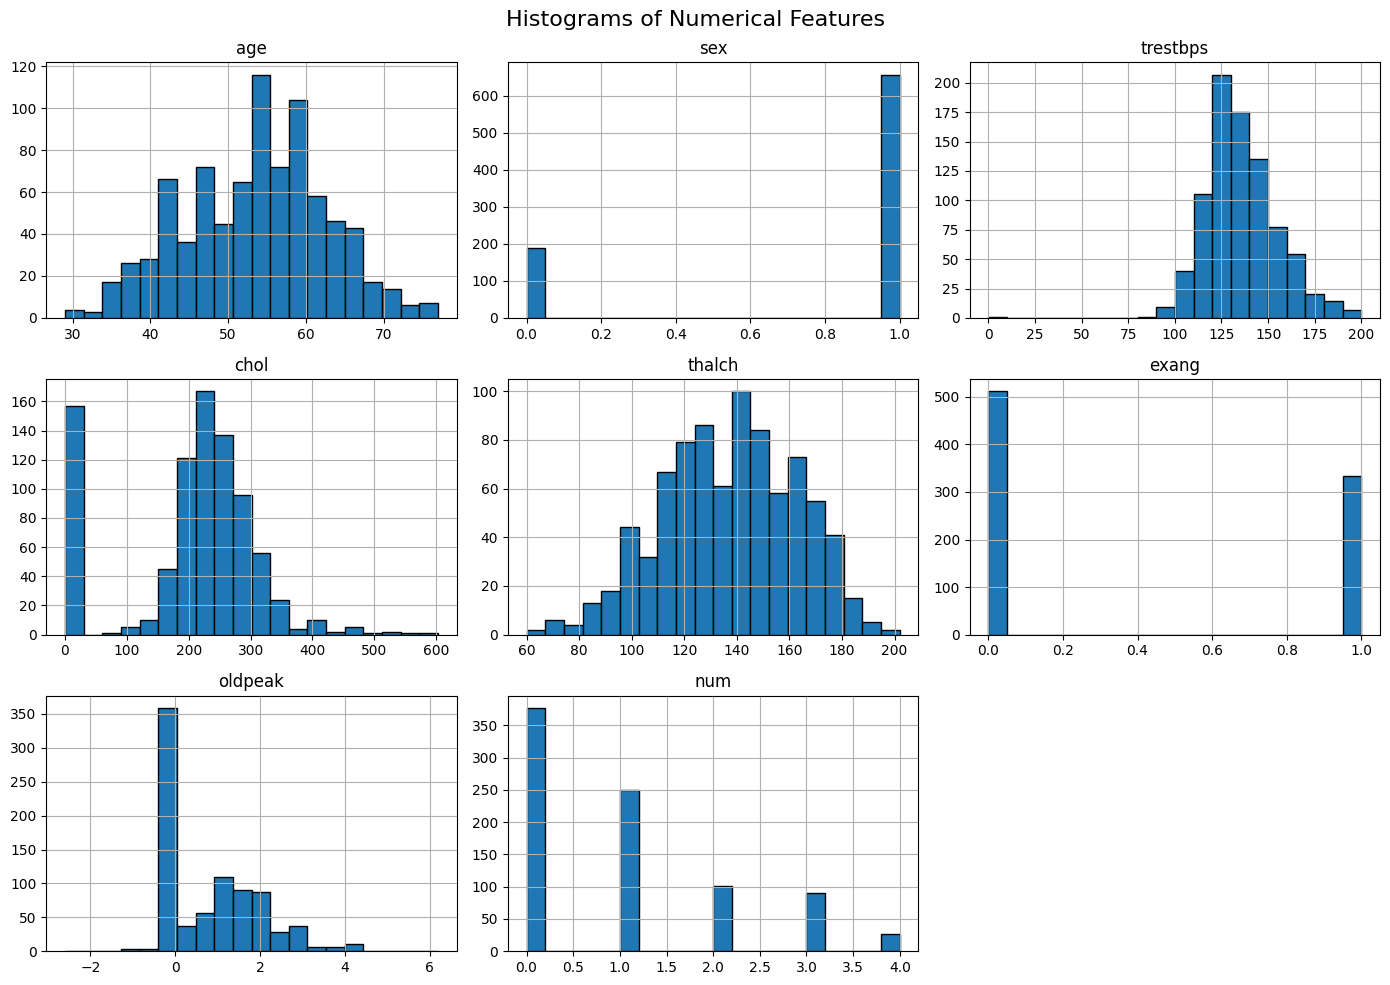

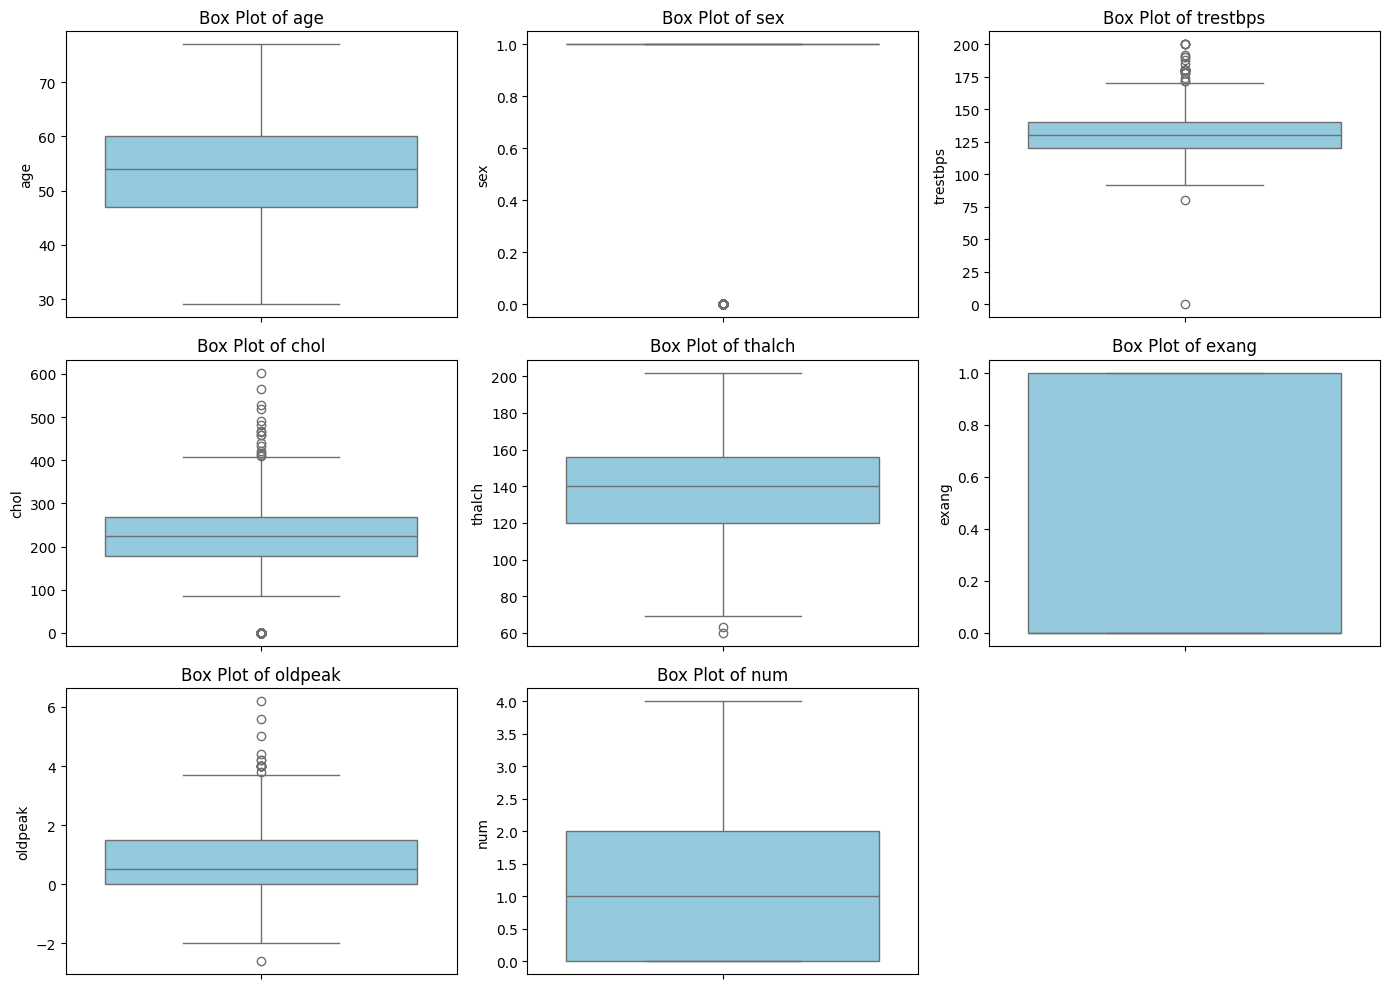

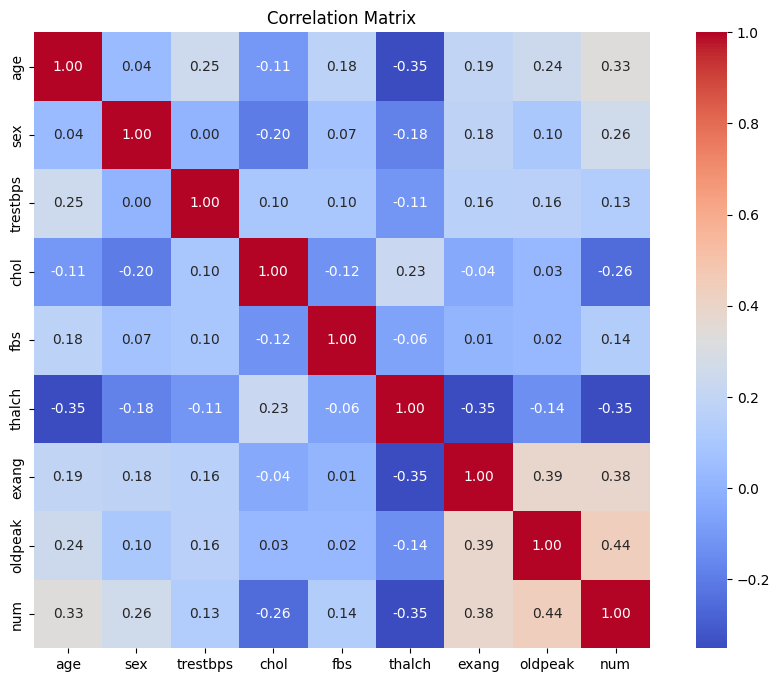

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
file_path = "heart_disease.xlsx"
df = pd.read_excel(file_path, sheet_name='Heart_disease')

# Convert categorical to numeric where useful
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['exang'] = df['exang'].map({'Yes': 1, 'No': 0, True: 1, False: 0})
df = df.dropna()

# ---------------- HISTOGRAMS ----------------
plt.figure(figsize=(14, 10))
df.hist(bins=20, figsize=(14, 10), edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# ---------------- BOX PLOTS ----------------
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(14, 10))
for i, column in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column], color='skyblue')
    plt.title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()

# ---------------- CORRELATION MATRIX ----------------
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

### **3. Feature Engineering:**

* **If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load dataset
file_path = "heart_disease.xlsx"
df = pd.read_excel(file_path, sheet_name='Heart_disease')

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the result
print(df_encoded.head())

   age  trestbps  chol  thalch  oldpeak  num  sex_Male  cp_atypical angina  \
0   63       145   233     150      2.3    0      True               False   
1   41       135   203     132      0.0    0      True                True   
2   57       140   192     148      0.4    0      True               False   
3   52       118   186     190      0.0    0      True               False   
4   57       110   201     126      1.5    0      True               False   

   cp_non-anginal  cp_typical angina  fbs_True  restecg_normal  \
0           False               True      True           False   
1           False              False     False            True   
2           False              False     False            True   
3           False               True     False           False   
4           False              False     False            True   

   restecg_st-t abnormality  exang_True  exang_FALSE  exang_TURE  slope_flat  \
0                     False       False        False  

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_excel("heart_disease.xlsx", sheet_name='Heart_disease')

# Identify numerical columns (excluding target if needed)
target_col = 'num'
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(target_col)

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform numerical features
scaled_array = scaler.fit_transform(df[numeric_cols])

# Create a DataFrame with scaled values
scaled_df = pd.DataFrame(scaled_array, columns=numeric_cols)

# Combine with the rest of the data (if desired)
df_scaled = df.copy()
df_scaled[numeric_cols] = scaled_df

# Show the result
print(df_scaled.head())

        age   sex               cp  trestbps      chol    fbs         restecg  \
0  1.006027  Male   typical angina  0.567394  0.281297   True  lv hypertrophy   
1 -1.397560  Male  atypical angina  0.076967  0.013526  False          normal   
2  0.350503  Male     asymptomatic  0.322181 -0.084656  False          normal   
3 -0.195767  Male   typical angina -0.756760 -0.138211  False  lv hypertrophy   
4  0.350503  Male     asymptomatic -1.149102 -0.004325  False          normal   

     thalch  exang   oldpeak        slope          thal  num  
0  0.524183  False  1.288612  downsloping  fixed defect    0  
1 -0.147705  False -0.815249         flat  fixed defect    0  
2  0.449529  False -0.449360         flat  fixed defect    0  
3  2.017268  False -0.815249         flat  fixed defect    0  
4 -0.371668   True  0.556834         flat  fixed defect    0  


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_excel("heart_disease.xlsx", sheet_name='Heart_disease')

# Show summary of missing values
print("Missing values per column:\n", df.isnull().sum())

# Strategy 1: Impute numeric columns with mean
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df[df_numeric.columns] = df_numeric.fillna(df_numeric.mean())

# Confirm missing values are handled
print("\nMissing values after imputation:\n", df.isnull().sum())

Missing values per column:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

Missing values after imputation:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64


### **4. Decision Tree Classification:**

* **Split the dataset into training and testing sets (e.g., using an 80-20 split).**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_excel("heart_disease.xlsx", sheet_name='Heart_disease')

# Separate features and target
X = df.drop(columns='num')  # Features
y = df['num']               # Target

# Perform 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # Ensures reproducibility
    stratify=y           # Optional: keeps class distribution balanced
)

# Output the shape of the splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (726, 12)
X_test shape: (182, 12)
y_train shape: (726,)
y_test shape: (182,)


* **Implement a Decision Tree Classification model using a library like scikit-learn.**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_excel('heart_disease.xlsx')

# Show basic info
print(df.head())
print(df.info())

# Encode categorical columns if any
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Separate features and target
X = df.drop('age', axis=1)
y = df['age']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train the model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)


# Predict and evaluate
y_pred = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
clf.fit(X_train, y_train)

        age                                       Age in years
0    Gender                       Gender ; Male - 1, Female -0
1        cp                                    Chest pain type
2  trestbps                             Resting blood pressure
3      chol                                cholesterol measure
4       fbs  (fasting blood sugar > 120 mg/dl) (1 = true; 0...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           12 non-null     object
 1   Age in years  12 non-null     object
dtypes: object(2)
memory usage: 324.0+ bytes
None
[[0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0
           5       0.00      0.00      0.00     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

DecisionTreeClassifier(random_state=42)

* **Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Sample dataset (Replace with actual data)
X = np.random.rand(1000, 10)  # Features
y = np.random.randint(0, 2, 1000)  # Binary target variable

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # For ROC-AUC calculation

# Evaluate the model
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba)
}

# Display the metrics
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")


Accuracy: 0.4650
Precision: 0.4118
Recall: 0.3804
F1-score: 0.3955
ROC-AUC: 0.4898


### **5. Hyperparameter Tuning:**

* **Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Sample dataset (Replace with actual data)
X = np.random.rand(1000, 10)  # Features
y = np.random.randint(0, 2, 1000)  # Binary target variable

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

# Perform GridSearchCV for tuning
grid_search = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")

# Train the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")


Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}
Test Set Accuracy: 0.5600


### **6. Model Evaluation and Analysis:**

* **Analyse the performance of the Decision Tree model using the evaluation metrics obtained.**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix & Classification Report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Display results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Accuracy: 0.5600
Precision: 0.5269
Recall: 0.5269
F1-score: 0.5269
ROC-AUC: 0.5359

Confusion Matrix:
[[63 44]
 [44 49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.59      0.59       107
           1       0.53      0.53      0.53        93

    accuracy                           0.56       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.56      0.56      0.56       200



* **Visualize the decision tree structure to understand the rules learned by the model and identify important features**

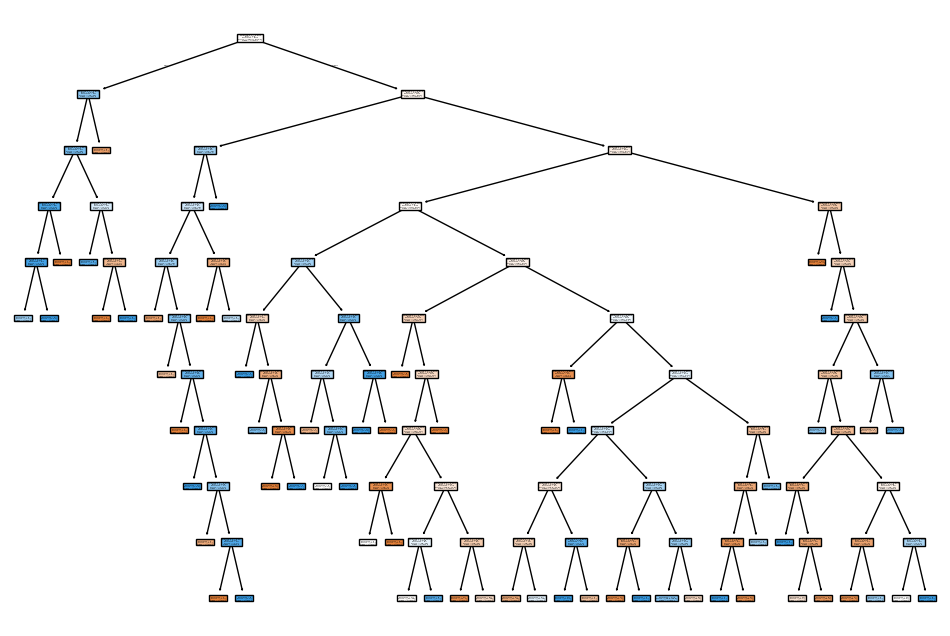

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(best_model, filled=True, feature_names=[f"Feature {i}" for i in range(X.shape[1])], class_names=["Class 0", "Class 1"])
plt.show()


In [ ]:
import numpy as np

# Get feature importances
importances = best_model.feature_importances_
feature_names = [f"Feature {i}" for i in range(X.shape[1])]

# Sort features by importance
sorted_indices = np.argsort(importances)[::-1]

# Display feature importance
print("Feature Importance Ranking:")
for idx in sorted_indices:
    print(f"{feature_names[idx]}: {importances[idx]:.4f}")

Feature Importance Ranking:
Feature 3: 0.1237
Feature 2: 0.1235
Feature 1: 0.1203
Feature 0: 0.1170
Feature 4: 0.1063
Feature 8: 0.1006
Feature 6: 0.0989
Feature 9: 0.0784
Feature 7: 0.0702
Feature 5: 0.0613


## **INTERVIEW QUESTIONS**

* **What are some common hyperparameters of decision tree models, and how do they affect the model's performance?**

Here are some common hyperparameters of decision tree models and how they affect performance:

1.	**max_depth:**

	•	Limits the depth of the tree.

	•	Effect: Prevents overfitting (if too deep) or underfitting (if too shallow).

2.	**min_samples_split:**

	•	Minimum number of samples required to split an internal node.

	•	Effect: Higher values make the tree more conservative, reducing overfitting.

3.	**min_samples_leaf:**

 •	Minimum number of samples required to be at a leaf node.

 •	Effect: Helps smooth the model and reduce overfitting.

4.	**max_features:**

	•	Number of features to consider when looking for the best split.

	•	Effect: Controls the randomness; lower values can increase bias, but improve generalization.

5.	**criterion (e.g., "gini" or "entropy"):**

 •	Function to measure the quality of a split.

 •	Effect: May slightly affect accuracy and training time depending on the dataset.

6.	**max_leaf_nodes:**

 •	Limits the number of leaf nodes.

 •	Effect: Helps control model complexity and overfitting.

7.	**splitter (e.g., "best" or "random"):**

  •	Strategy to choose the split at each node.

	•	Effect: "random" adds more variance, useful in ensemble methods like Random Forests.

* **What is the difference between the Label encoding and One-hot encoding?**

-->**Label Encoding:**

•**	Definition:** Converts each category into a unique integer (e.g., Red = 0, Green = 1, Blue = 2).

•	**Output:** Single column with integer values.

•	**Use Case:**Suitable for ordinal data (where categories have a meaningful order, like “Low”, “Medium”, “High”).

•	**Risk:** For nominal data (no inherent order), the model may mistakenly interpret the numbers as ordered, leading to misleading results.

-->**One-Hot Encoding:**

•	**Definition:** Creates a new binary column for each category (e.g., Red = [1,0,0], Green = [0,1,0], Blue = [0,0,1]).

•	**Output:** Multiple columns (one per category), with 0s and 1s.

•	**Use Case:** Preferred for nominal data (no order among categories).

•	**Drawback:** Can lead to a high-dimensional dataset if there are many unique categories.

-->**Differences:**

Label Encoding and One-Hot Encoding are two techniques used to convert categorical data into numerical format so that machine learning algorithms can process them. Label Encoding assigns each unique category in a feature an integer value. For example, if a feature “Color” has categories Red, Green, and Blue, they might be encoded as 0, 1, and 2 respectively. This method is simple and memory-efficient, but it introduces an implicit ordinal relationship between categories, which can mislead algorithms that interpret higher values as more important. Therefore, it is better suited for ordinal data, where the categories have a natural order (like “Low”, “Medium”, “High”).

